# Testing Engram on LongMemEval

### Meta

LongMemEval was originally published October 14th, 2024 on ArXiv and then accepted to ICLR 2025.<br />
It has been fairly well adopted, achieving 178 citations at the time of this writing.<br />
At the time of this writing, it is the most popularly used benchmark for conversational memory.<br />

### Overview

It consists of 500 questions whose answers are embedded within user-assistant chat histories. <br />
It is designed to test five core memory abilities: information extraction, multi-session reasoning, knowledge updates, temporal reasoning, and abstention on unanswerable questions.<br />
I think the key distinction is about how many answer sessions are in each chat history. For example, you have 174 / 500 with a single answer session, and then on the tail end you have 14 / 500 with either 5 or 6 answer sessions. The benchmark is designed intentionally to have the answer evidence be scattered across up to six sessions.<br />

### Scale and Cost

The benchmark comes in two standard sizes — `LongMemEval-S` (~115K tokens per question) and `LongMemEval-M` (500 sessions, ~1.5M tokens). `LongMemEval-M` is an absurdly massive size. This would entail ~500M input tokens, so $1,250 just on that.

LongMemEval-S would cost about $180 to ingest with Engram using GPT-5.4.
52 Million Input Tokens at $2.5 per 1M ==> $130

From some early testing I am seeing an average of ~300 memories either created or updated per session.<br />
So on the output tokens,<br />

300 memories * 20 tokens per memory = 6,000 output tokens * 500 sessions = 3M * $15 per 1M = $45

Total = ~$175 ($130 input, $45 output), for `LongMemEval-S`

The cost is mostly on the input side, but still non-negligible output cost as well.

### Notebook

This notebook:

- Visualizes the tokens per document and answer session distribution
- Setups up a Question Answering system using Engram `search`
- Ingests 2 sessions into Engram to demonstrate what this benchmark entails

### Imports

In [ ]:
from collections import Counter, defaultdict
from datasets import load_dataset
import matplotlib.pyplot as plt
from pydantic import BaseModel
import time
import os

import tiktoken
ENCODING = tiktoken.get_encoding("cl100k_base")
def safe_token_count(text):
    """Count tokens, handling special token edge cases."""
    try:
        return len(ENCODING.encode(text, disallowed_special=()))
    except Exception:
        return 0
 
import dspy
lm = dspy.LM("openai/gpt-5.4", api_key=os.environ["OPENAI_API_KEY"])
dspy.configure(lm=lm)

import engram
from engram import EngramClient, RetrievalConfig

print(engram.__version__)

0.5.0


### Load Data

In [ ]:
raw_docs = load_dataset("weaviate/longmemeval-s-cleaned", "docs")["train"]
raw_queries = load_dataset("weaviate/longmemeval-s-cleaned", "queries")["train"]
 
docs_by_tenant = defaultdict(list)
for item in raw_docs:
    docs_by_tenant[str(item["tenant_id"])].append(dict(item))
 
queries_by_tenant = defaultdict(list)
for item in raw_queries:
    queries_by_tenant[str(item["tenant_id"])].append(dict(item))
 
print(f"Loaded {len(docs_by_tenant)} tenants")

Loaded 500 tenants


### Analyze Tokens per Documnet

Total docs:    23,867
Total queries: 500
Total tokens:  52,033,286
Tokens/doc:    min=6  avg=2,180  max=17,263


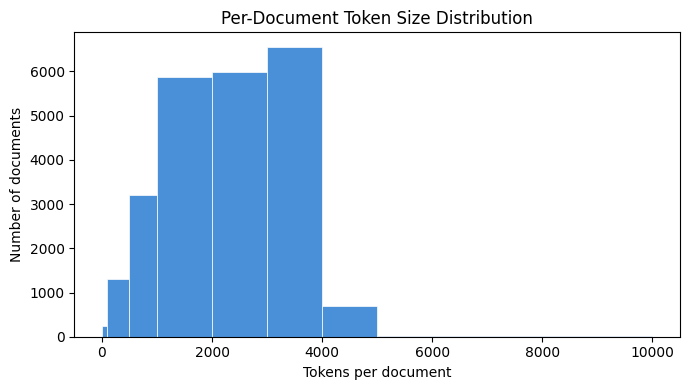

In [38]:
total_docs = sum(len(d) for d in docs_by_tenant.values())
total_queries = sum(len(q) for q in queries_by_tenant.values())
token_counts = [
    safe_token_count(doc["session_text"])
    for docs in docs_by_tenant.values()
    for doc in docs
]
 
print(f"Total docs:    {total_docs:,}")
print(f"Total queries: {total_queries:,}")
print(f"Total tokens:  {sum(token_counts):,}")
print(f"Tokens/doc:    min={min(token_counts):,}  avg={sum(token_counts)//len(token_counts):,}  max={max(token_counts):,}")

bins = [0, 100, 500, 1000, 2000, 3000, 4000, 5000, 10000]
 
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(token_counts, bins=bins, color="#4a90d9", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Tokens per document")
ax.set_ylabel("Number of documents")
ax.set_title("Per-Document Token Size Distribution")
fig.tight_layout()
plt.show()

### Analyze Number of Answer Sessions per User

Answer session count distribution by tenant: {1: 176, 3: 41, 4: 19, 2: 250, 5: 11, 6: 3}


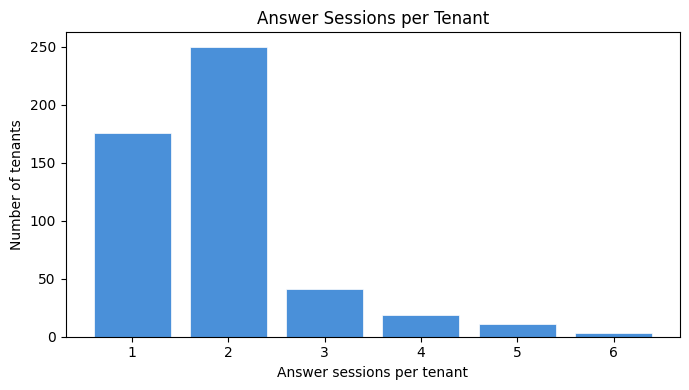

In [44]:
answer_counts = []
for docs in docs_by_tenant.values():
    n = sum(1 for d in docs if d["session_id"].startswith("answer_"))
    answer_counts.append(n)

dist = Counter(answer_counts)
print("Answer session count distribution by tenant:", dict(dist))

keys = sorted(dist.keys())
values = [dist[k] for k in keys]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(keys, values, color="#4a90d9", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Answer sessions per tenant")
ax.set_ylabel("Number of tenants")
ax.set_title("Answer Sessions per Tenant")
ax.set_xticks(keys)
fig.tight_layout()
plt.show()

### Visualize Sessions

In [12]:
from matplotlib.patches import Patch
 
all_tenant_ids = sorted(docs_by_tenant.keys())
 
 
def inspect_tenant(idx):
    """Visualize token distribution for tenant at index idx (0-499)."""
    tenant_id = all_tenant_ids[idx]
    docs = docs_by_tenant[tenant_id]
    queries = queries_by_tenant.get(tenant_id, [])
 
    session_ids = [d["session_id"] for d in docs]
    tokens = [safe_token_count(d["session_text"]) for d in docs]
    is_answer = [sid.startswith("answer_") for sid in session_ids]
    colors = ["#e74c3c" if a else "#4a90d9" for a in is_answer]
 
    fig, ax = plt.subplots(figsize=(max(8, len(docs) * 0.4), 4))
    ax.bar(range(len(docs)), tokens, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Session index")
    ax.set_ylabel("Tokens")
    ax.set_title(f"Tenant {tenant_id} (idx={idx}): {len(docs)} sessions, {len(queries)} queries")
    ax.legend(
        handles=[Patch(color="#4a90d9", label="Session"), Patch(color="#e74c3c", label="Answer session")],
        loc="upper right",
    )
    fig.tight_layout()
    plt.show()
 
    for sid, tok, ans in zip(session_ids, tokens, is_answer):
        if ans:
            print(f"  Answer session: {sid} — {tok:,} tokens")
    for i, q in enumerate(queries, 1):
        print(f"  Q{i}: {q['question']}")
        print(f"      Answer IDs: {q['answer_session_ids']}")

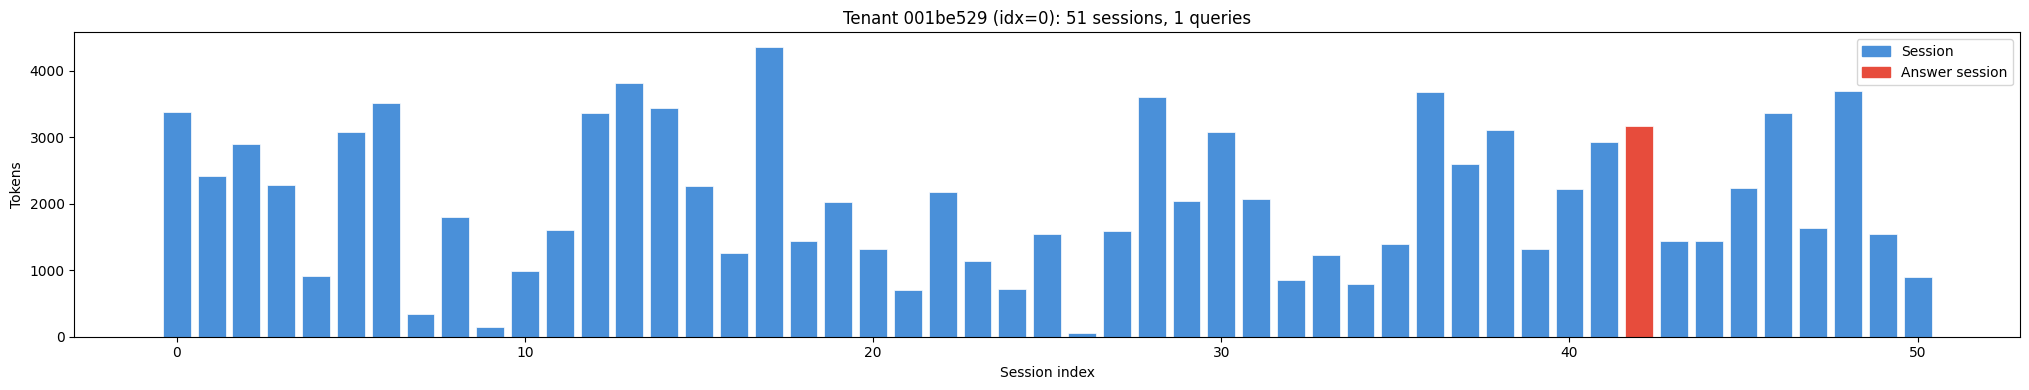

  Answer session: answer_530960c1 — 3,165 tokens
  Q1: How long did I wait for the decision on my asylum application?
      Answer IDs: ['answer_530960c1']


In [13]:
inspect_tenant(0)

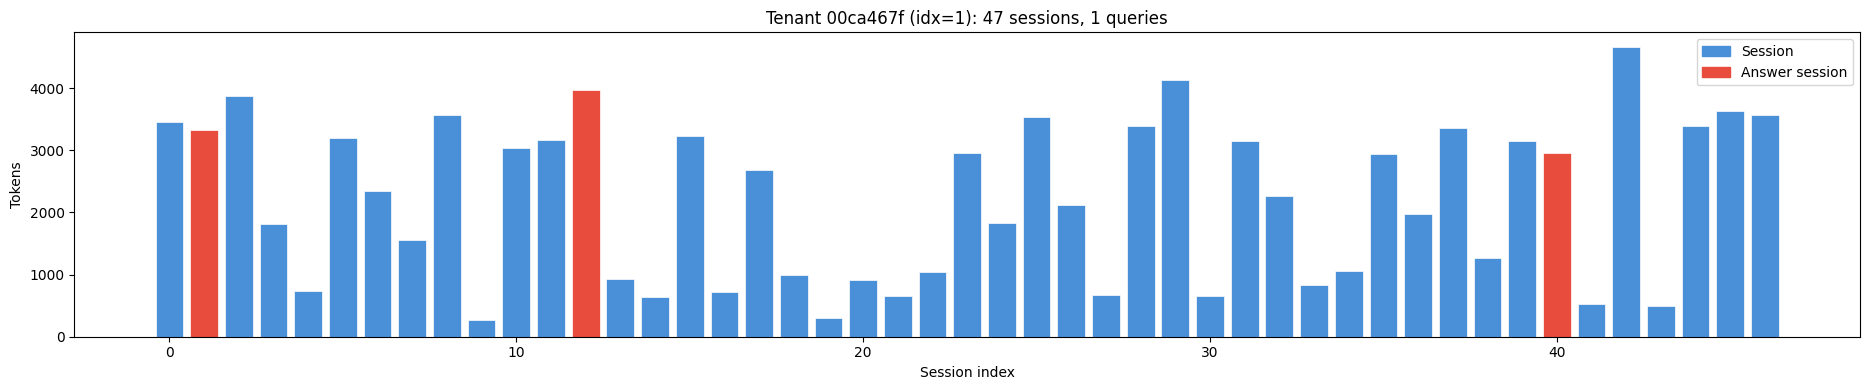

  Answer session: answer_39900a0a_3 — 3,330 tokens
  Answer session: answer_39900a0a_2 — 3,968 tokens
  Answer session: answer_39900a0a_1 — 2,965 tokens
  Q1: How many doctor's appointments did I go to in March?
      Answer IDs: ['answer_39900a0a_3', 'answer_39900a0a_2', 'answer_39900a0a_1']


In [15]:
inspect_tenant(1)

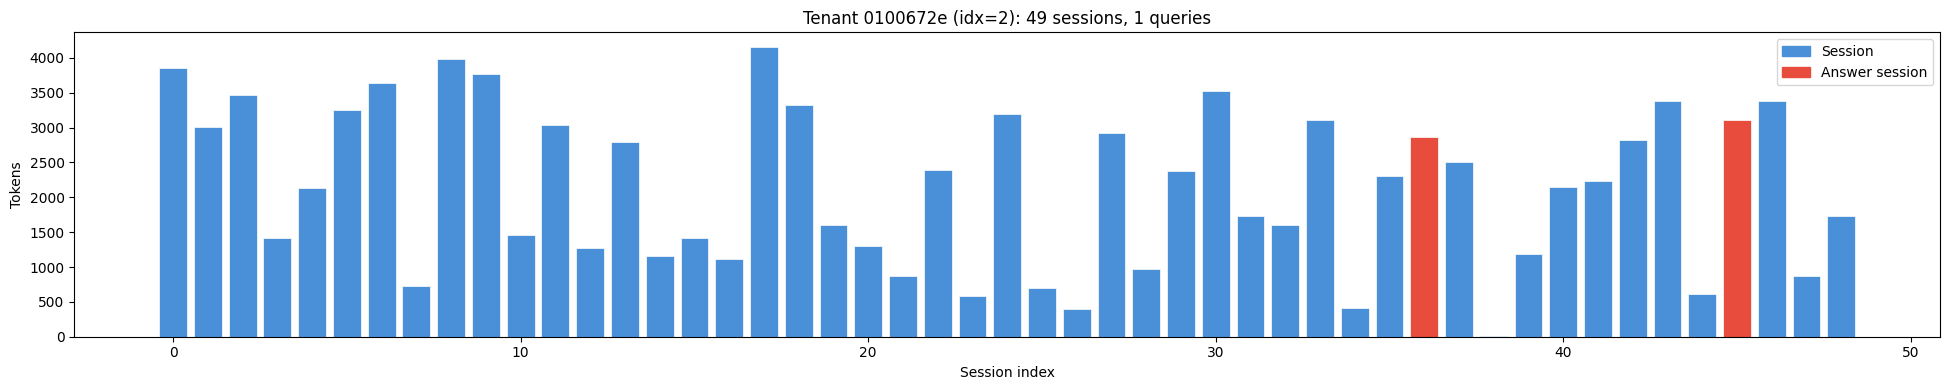

  Answer session: answer_35c9798c_2 — 2,868 tokens
  Answer session: answer_35c9798c_1 — 3,115 tokens
  Q1: How much did I spend on each coffee mug for my coworkers?
      Answer IDs: ['answer_35c9798c_2', 'answer_35c9798c_1']


In [39]:
inspect_tenant(2)

### QA System

In [ ]:
class MemoryWithTimestamp(BaseModel):
    memory: str
    time_added: str

class AnswerUserQueryWithMemory(dspy.Signature):
    """Review the retrieved memories about the user to answer their question."""

    user_question: str = dspy.InputField()
    retrieved_memories: list[MemoryWithTimestamp] = dspy.InputField()
    answer: str = dspy.OutputField()

qa_system = dspy.Predict(AnswerUserQueryWithMemory)

class AssessAlignment(dspy.Signature):
    """Evaluate whether the system answer is aligned with the ground truth answer."""

    system_answer: str = dspy.InputField()
    ground_truth_answer: str = dspy.InputField()
    alignment_score: bool = dspy.OutputField()

lm_judge = dspy.Predict(AssessAlignment)

In [18]:
# Toy test block
query = "What is my favorite flavor of ice cream?"
ground_truth_answer = "chocolate"

mock_memories: list[MemoryWithTimestamp] = [
    MemoryWithTimestamp(memory="User loves chocolate ice cream.", time_added="2025-01-15T10:00:00Z"),
    MemoryWithTimestamp(memory="User is lactose intolerant but makes exceptions for ice cream.", time_added="2025-02-01T14:30:00Z"),
]

response = qa_system(user_question=query, retrieved_memories=mock_memories)
print(f"Q: {query}")
print(f"A: {response.answer}")

judgment = lm_judge(system_answer=response.answer, ground_truth_answer=ground_truth_answer)
print(f"Aligned: {judgment.alignment_score}")

Q: What is my favorite flavor of ice cream?
A: Your favorite ice cream flavor is chocolate.
Aligned: True


### Engram Memory Ingestion

In [31]:
engram_client = EngramClient(
    api_key=os.environ["ENGRAM_API_KEY"],
    base_url="https://dev-engram.labs.weaviate.io",
)

In [32]:
def print_memories(memories: list[tuple[str, str]], user_id: str, group: str = "default") -> None:
    """Fetch and print memory content with operation type."""
    for mid, op_type in memories:
        memory = engram.memories.get(mid, user_id=user_id, group=group)
        print(f"    [{op_type}] {memory.content}")

def ingest_docs_to_engram(tenant_idx: int) -> None:
    """Upload all sessions for a tenant to Engram. Fires all off with ordering delay, waits only on the last."""
    user_id: str = f"longmemeval-{all_tenant_ids[tenant_idx]}"
 
    docs: list[dict] = docs_by_tenant[all_tenant_ids[tenant_idx]]
    n_answer: int = sum(1 for d in docs if d["session_id"].startswith("answer_"))
    print(f"Tenant: {all_tenant_ids[tenant_idx]} | {len(docs)} sessions ({n_answer} answer)\n")
 
    t0: float = time.time()
    run_ids: list[str] = []
    answer_run_idxs: list[int] = []
 
    for i, doc in enumerate(docs):
        sid: str = doc["session_id"]
        run = engram.memories.add(doc["session_text"], user_id=user_id, group="default")
        run_ids.append(run.run_id)
 
        if sid.startswith("answer_"):
            answer_run_idxs.append(i)
            print(f"  [{i+1}/{len(docs)}] {sid} — {safe_token_count(doc['session_text']):,} tokens (answer)")
 
        if (i + 1) % 10 == 0:
            print(f"  [{i+1}/{len(docs)}] submitted")
 
        time.sleep(0.1)
 
    # Wait for the last run to complete
    last_run_id: str = run_ids[-1]
    while True:
        status = engram.runs.get(last_run_id)
        if status.status in ("completed", "failed", "deleted"):
            break
        time.sleep(5)
 
    elapsed: float = time.time() - t0
    print(f"\n  All {len(docs)} sessions processed in {elapsed:.0f}s")
 
    # Collect per-run memory operation counts
    created_counts: list[int] = []
    updated_counts: list[int] = []
    deleted_counts: list[int] = []
 
    for run_id in run_ids:
        run_status = engram.runs.get(run_id)
        ops = run_status.committed_operations
        created_counts.append(len(getattr(ops, "created", [])))
        updated_counts.append(len(getattr(ops, "updated", [])))
        deleted_counts.append(len(getattr(ops, "deleted", [])))
 
    def _stats(counts: list[int]) -> str:
        return f"min={min(counts)} avg={sum(counts)/len(counts):.1f} max={max(counts)} total={sum(counts)}"
 
    print(f"  Created:  {_stats(created_counts)}")
    print(f"  Updated:  {_stats(updated_counts)}")
    print(f"  Deleted:  {_stats(deleted_counts)}")
 
    # Print answer session memories
    for idx in answer_run_idxs:
        answer_status = engram.runs.get(run_ids[idx])
        ops = answer_status.committed_operations
        answer_memories: list[tuple[str, str]] = []
        for op in getattr(ops, "created", []):
            answer_memories.append((op.memory_id, "created"))
        for op in getattr(ops, "updated", []):
            answer_memories.append((op.memory_id, "updated"))
        for op in getattr(ops, "deleted", []):
            answer_memories.append((op.memory_id, "deleted"))
 
        sid: str = docs[idx]["session_id"]
        print(f"\n  Answer session {sid}: {len(answer_memories)} memories")
        print_memories(answer_memories, user_id=user_id)

In [36]:
def evaluate_tenant(tenant_idx: int, k: int = 5) -> dict:
    """Search Engram for the tenant's query and assess alignment with ground truth."""
    tenant_id: str = all_tenant_ids[tenant_idx]
    user_id: str = f"longmemeval-{tenant_id}"
    q: dict = queries_by_tenant[tenant_id][0]
 
    memories = engram_client.memories.search(
        query=q["question"],
        user_id=user_id,
        group="default",
        retrieval_config=RetrievalConfig(retrieval_type="hybrid", limit=k),
    )
    retrieved: list[MemoryWithTimestamp] = [
        MemoryWithTimestamp(memory=m.content, time_added=str(m.created_at))
        for m in memories
    ]
 
    response = qa_system(user_question=q["question"], retrieved_memories=retrieved)
    judgment = lm_judge(system_answer=response.answer, ground_truth_answer=q["answer"])
 
    print(f"  Q: {q['question']}")
    print(f"  GT: {q['answer']}")
    print(f"  System: {response.answer}")
    print(f"  Aligned: {judgment.alignment_score}")
 
    return {
        "tenant_id": tenant_id,
        "question": q["question"],
        "ground_truth": q["answer"],
        "system_answer": response.answer,
        "aligned": judgment.alignment_score,
        "n_memories_retrieved": len(retrieved),
    }

### Test 1

Question: `How long did I wait for the decision on my asylum application?`

Number of answer sessions: 1

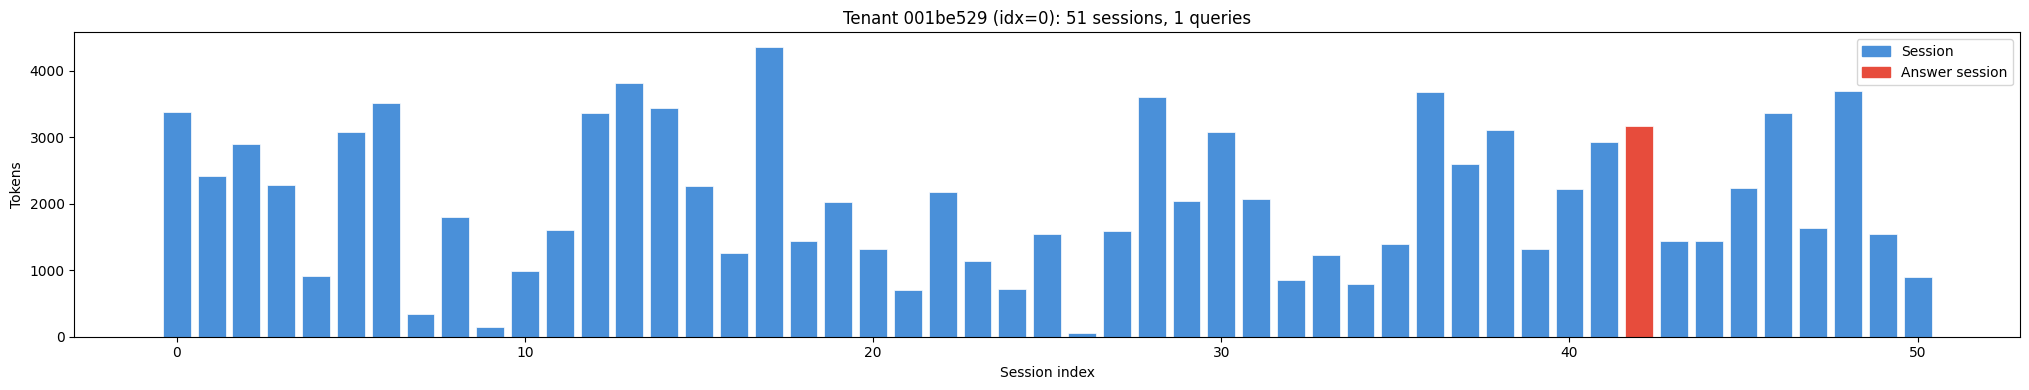

  Answer session: answer_530960c1 — 3,165 tokens
  Q1: How long did I wait for the decision on my asylum application?
      Answer IDs: ['answer_530960c1']


In [25]:
inspect_tenant(0)

In [23]:
TENANT_IDX: int = 0

ingest_docs_to_engram(TENANT_IDX)

Tenant: 001be529 | 51 sessions (1 answer)

  [10/51] submitted
  [20/51] submitted
  [30/51] submitted
  [40/51] submitted
  [43/51] answer_530960c1 — 3,165 tokens (answer)
  [50/51] submitted

  All 51 sessions processed in 940s
  Answer session: 12 memories
    [ce8797ea-78da-487b-a7e8-64871934542f] User has been using Zillow to search for apartments.
    [c27c0e4c-a90c-450f-9c74-c309fc8f7c1e] User's volunteer work helps them meet like-minded people.
    [4ddcc208-10fa-44c6-b234-f738e8244d05] User's asylum application was approved after over a year of waiting.
    [892d6911-357f-411e-91f3-18764c3e54df] User is trying to find a permanent place to live on a limited budget.
    [990e1ceb-bd89-42e6-8657-214c5723067f] User has some savings for a security deposit and first month's rent.
    [1955e208-fa13-4d10-ae9f-be7d673e347a] User needs housing close to public transportation.
    [6f7c5dde-0ba8-407c-b21b-15393cc66334] User needs housing close to their volunteer job.
    [6b1890d8-261b-4

In [24]:
results = evaluate_tenant(0)

  Q: How long did I wait for the decision on my asylum application?
  GT: over a year
  System: You waited over a year for the decision on your asylum application.
  Aligned: True


### Test 2

Question: `How many doctor's appointments did I go to in March?`

Number of answer sessions: 3

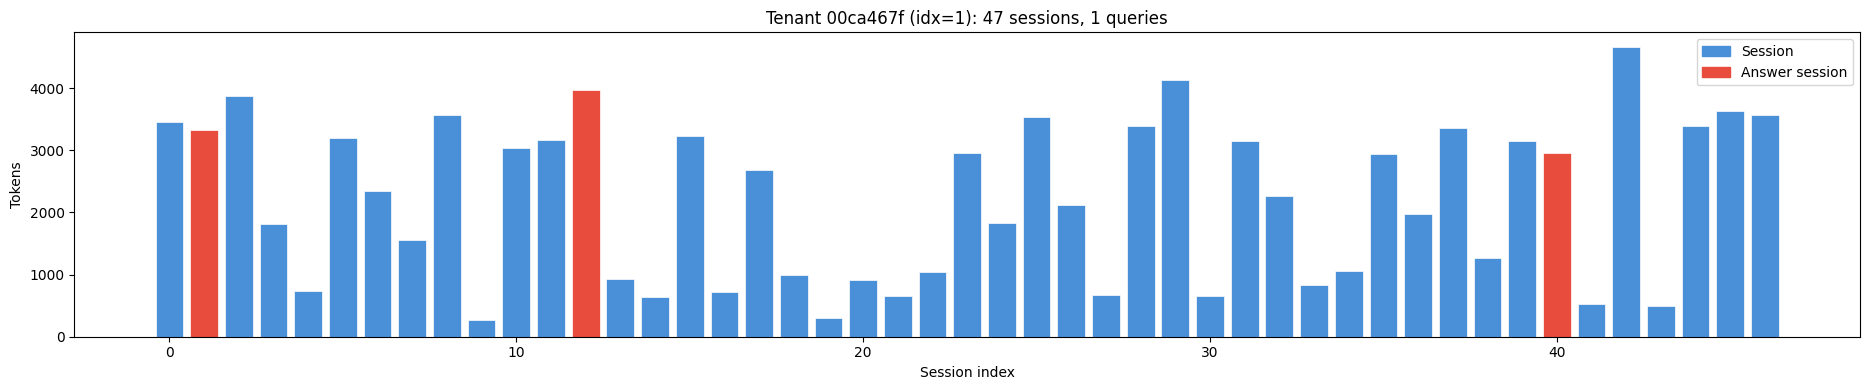

  Answer session: answer_39900a0a_3 — 3,330 tokens
  Answer session: answer_39900a0a_2 — 3,968 tokens
  Answer session: answer_39900a0a_1 — 2,965 tokens
  Q1: How many doctor's appointments did I go to in March?
      Answer IDs: ['answer_39900a0a_3', 'answer_39900a0a_2', 'answer_39900a0a_1']


In [33]:
inspect_tenant(1)

In [34]:
TENANT_IDX: int = 1

ingest_docs_to_engram(TENANT_IDX)

Tenant: 00ca467f | 47 sessions (3 answer)

  [2/47] answer_39900a0a_3 — 3,330 tokens (answer)
  [10/47] submitted
  [13/47] answer_39900a0a_2 — 3,968 tokens (answer)
  [20/47] submitted
  [30/47] submitted
  [40/47] submitted
  [41/47] answer_39900a0a_1 — 2,965 tokens (answer)

  All 47 sessions processed in 807s
  Created:  min=0 avg=5.6 max=14 total=265
  Updated:  min=0 avg=0.4 max=3 total=21
  Deleted:  min=0 avg=0.0 max=1 total=2

  Answer session answer_39900a0a_3: 7 memories
    [created] The user has had a lingering/persistent cough for about six weeks that was not fully cleared by an antibiotic prescribed by their primary care physician (Dr. Smith). They saw Dr. Smith on March 3 and were diagnosed with bronchitis; symptoms are worse at night with discomfort and waking up with a bad cough. They are considering getting a chest X-ray to rule out other issues related to the persistent cough.
    [created] The user is recovering from a torn ACL. At a follow-up appointment with orth

In [35]:
results = evaluate_tenant(TENANT_IDX)

  Q: How many doctor's appointments did I go to in March?
  GT: 2
  System: Based on the memories, you went to 1 doctor's appointment in March: a follow-up with orthopedic surgeon Dr. Thompson on March 20.

There was also left-hand numbness first noticed around March 15, but no March doctor visit for that is mentioned. The neurologist EMG is scheduled for April 1, not March.
  Aligned: False


### Maybe increasing the K will help...

In [37]:
results = evaluate_tenant(TENANT_IDX, 10)

  Q: How many doctor's appointments did I go to in March?
  GT: 2
  System: Based on the memories, you went to 1 doctor's appointment in March: a follow-up with orthopedic surgeon Dr. Thompson on March 20.

There was also left-hand numbness noticed around March 15, but no March doctor's visit for that is mentioned. The neurologist EMG is scheduled for April 1, so that does not count for March.
  Aligned: False


In [43]:
results = evaluate_tenant(TENANT_IDX, 20)

  Q: How many doctor's appointments did I go to in March?
  GT: 2
  System: Based on the memories, you went to **2 doctor’s appointments in March**:

1. **March 3** — appointment with **Dr. Smith** for bronchitis/persistent cough  
2. **March 20** — follow-up with **Dr. Thompson** for your torn ACL

I didn’t count the April 1 EMG since that’s in April, and the gastroenterologist visit was only something you were considering scheduling.
  Aligned: True
